# REE Separation from Bastnasite Concentrate

This notebook builds a single extract-scrub-strip circuit on a **bastnasite**
concentrate leach liquor and works it through to a cost structure, using
`difflow_ree`.

## What this notebook is, and is not

It is a worked example of the *machinery*: how to put a real ore composition on
a defensible basis, how to read a distribution-coefficient correlation and stay
inside the window it was fitted over, how to close a mass balance across every
outlet of a circuit with an internal recycle, and how a cost estimate responds
to the design.

It is **not** a technoeconomic evaluation of a rare earth project, and no number
printed below should be quoted as one. The reason is entirely about data, not
about the code: the PC88A distribution coefficients in this package are
`HAND_TUNED` — chosen so demos behave, with no external basis — and every price
and cost factor is `ESTIMATED`, meaning an indicative order of magnitude with no
identified source. Section 0 makes that explicit from the database itself rather
than asking you to take it on trust.

## Process

1. **Feed** — Mountain Pass bastnasite REO distribution, on a rare-earth-oxide basis
2. **Equilibrium** — PC88A distribution coefficients, checked against the
   correlation's own validity range
3. **Extract-scrub-strip** — one PC88A circuit: Nd and heavies to the strip
   liquor, La and Ce to the raffinate
4. **Streams** — the scrub recycle closed, and the balance struck on every
   external outlet
5. **Cost structure** — contained-oxide value at an explicit payability, against
   factored CAPEX/OPEX

In [1]:
import warnings

import jax
import jax.numpy as jnp
import numpy as np

jax.config.update("jax_enable_x64", True)

from difflow.streams import make_stream, get_flows

from difflow_ree import (
    # Database
    get_element, list_ree_elements, get_extractant,
    # Equilibrium
    REEDistribution,
    # Flowsheets
    ExtractScrubStripCircuit, ExtractScrubStripParams,
    # Economics
    REEPricing, estimate_capex, capex_basis, estimate_opex, calculate_profit,
    ree_oxide_mass_flow,
)
from difflow_ree.database import get_separation_factor
from difflow_ree.provenance import audit, coverage, explain

HOURS_PER_YEAR = 8000.0
T_OP = 298.15

print("REE elements in database:", list_ree_elements())

REE elements in database: ['La', 'Ce', 'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Y', 'Ho', 'Er', 'Tm', 'Yb', 'Lu']


## 0. Provenance: what the numbers below are worth

`difflow_ree` tags every leaf value in its data files with a provenance class,
resolvable from Python. Before running anything, ask the database what class of
number this notebook is about to depend on.

The two that matter here:

- **`HAND_TUNED`** — "chosen so that example code produces reasonable
  behaviour", no external basis of any kind. This is what PC88A's
  `ph_coefficients` are, and they set every distribution coefficient, hence
  every recovery and purity in this notebook.
- **`ESTIMATED`** — an indicative order of magnitude, no identified source.
  This is what every REE price is.

So: the *shape* of the answers here is meaningful (heavies extract harder than
lights, Nd harder than Pr, extraction improves with pH), because that ordering
is the one physical thing the hand-tuning got right. The *magnitudes* are not.

In [2]:
print("Provenance census of the extractant database")
print("=" * 62)
for cls, n in sorted(coverage("extractants").items(), key=lambda kv: -kv[1]):
    print(f"  {cls:<12} {n:>4} values")

print("\nWhat this notebook's distribution coefficients actually are")
print("=" * 62)
p = explain("extractants", "extractants.PC88A.ph_coefficients.Nd.b")
print(f"  path : {p.path}")
print(f"  value: {p.value}")
print(f"  class: {p.cls}")
print(f"  cite : {p.citation}")

hand_tuned = audit(cls="HAND_TUNED")
pc88a = [q for q in hand_tuned if ".PC88A." in q.path]
print(f"\n  {len(hand_tuned)} HAND_TUNED values in the database, "
      f"{len(pc88a)} of them in the PC88A record")

print("\nAnd what the prices are")
print("=" * 62)
q = explain("elements", "elements.Nd.price_usd_kg")
print(f"  elements.Nd.price_usd_kg = {q.value}  [{q.cls}]")
print(f"  {q.source_note.split('Do not')[0].strip()[:220]}")
print("\n  -> Every price in this notebook is ESTIMATED. Nothing downstream of")
print("     one is a project number. See difflow_ree/economics/costs.py, which")
print("     says the same thing about every cost factor it contains.")

Provenance census of the extractant database
  HAND_TUNED    161 values
  CONVENTION     94 values
  MEASURED       76 values
  REFERENCE      57 values
  ESTIMATED       9 values
  DERIVED         4 values

What this notebook's distribution coefficients actually are
  path : extractants.PC88A.ph_coefficients.Nd.b
  value: 2.55
  class: HAND_TUNED
  cite : Chosen so that example code produces reasonable behaviour.

  161 HAND_TUNED values in the database, 53 of them in the PC88A record

And what the prices are
  elements.Nd.price_usd_kg = 120.0  [ESTIMATED]
  Order of magnitude only. EVERY PRICE IN THIS DATABASE IS EST, including those of the ten elements that predate this registry. Rare earth prices move by factors of several within a year, differ between metal and oxide, an

  -> Every price in this notebook is ESTIMATED. Nothing downstream of
     one is a project number. See difflow_ree/economics/costs.py, which
     says the same thing about every cost factor it contains.


## 1. Bastnasite feed, on a rare-earth-oxide basis

Bastnasite is `(REE)CO3F`. The Mountain Pass (California) deposit is the
canonical light-REE bastnasite: roughly half the contained rare earth is cerium
and a third is lanthanum, which is exactly why the economics below come out the
way they do — the bulk of the feed is the part of the market that is in
surplus.

The composition is specified the way ore is actually reported: **weight percent
of total rare earth oxide (REO)**. Two things follow from that, and both are
easy to get wrong.

**Prices are quoted per kg of oxide, not per kg of metal.** Converting between
them is not one factor, because the oxide stoichiometry differs by element:
`La2O3` and `Nd2O3` carry two metal atoms per formula, `CeO2` carries one, and
`Pr6O11` carries six. Multiplying a metal mass by an oxide price understates
the value of a stream by 13 % (Dy) to 21 % (Y), and by a different amount for
each element — so it distorts the *ranking* of which element is carrying the
revenue, not just the level. `difflow_ree.ree_oxide_mass_flow` does the
conversion properly, and is used for every mass reported in the economics
below.

**"500 t/year REO" has to mean REO.** A plant basis stated in oxide tonnes and
a set of molar flows written down by hand will not agree unless something forces
them to: the same distribution priced on a metal basis is only about 195 t/yr,
so the label and the simulation can disagree by a factor of 2.5 while both look
reasonable. Here the molar flows are *derived* from the target REO tonnage and
the round-trip through `ree_oxide_mass_flow` is asserted, so the stated basis
and the simulated basis cannot drift apart.

In [3]:
# Mountain Pass bastnasite: distribution of the contained rare earth,
# as wt% of total REO. Indicative of the published ore description; the
# element *ratios* are the point, not the third significant figure.
REO_DISTRIBUTION = {
    "La": 33.8,
    "Ce": 49.6,   # half the feed, and the cheapest REE on the market
    "Pr": 4.1,
    "Nd": 11.2,   # the magnet element; the reason the plant exists
    "Sm": 0.9,
    "Eu": 0.1,
    "Gd": 0.2,
    "Dy": 0.03,   # bastnasite is heavy-poor; Dy is a trace here
    "Y": 0.1,
}
REO_TONNES_PER_YEAR = 500.0   # plant basis, tonnes REO/year

# Oxide formulas differ in metal atoms per formula unit, so the metal-to-oxide
# conversion is per element. This is the only place in the notebook that does
# the conversion by hand; everything downstream calls ree_oxide_mass_flow.
METAL_ATOMS = {"Ce": 1, "Pr": 6, "Tb": 4}   # everything else is R2O3

_total_pct = sum(REO_DISTRIBUTION.values())
reo_kg_s = REO_TONNES_PER_YEAR * 1000.0 / (HOURS_PER_YEAR * 3600.0)

bastnasite_composition = {}
for elem, pct in REO_DISTRIBUTION.items():
    props = get_element(elem)
    n_metal = METAL_ATOMS.get(elem, 2)
    oxide_kg_s = reo_kg_s * pct / _total_pct
    # kg oxide/s -> mol metal/s
    bastnasite_composition[elem] = oxide_kg_s * 1000.0 / (props.oxide_mw / n_metal)

all_elements = tuple(bastnasite_composition)

# The basis must close: molar flows -> contained REO -> the tonnage we asked for
reo_check = float(ree_oxide_mass_flow(bastnasite_composition))
assert abs(reo_check - reo_kg_s) / reo_kg_s < 1e-10, "REO basis does not close"

print(f"Bastnasite leach liquor: {REO_TONNES_PER_YEAR:.0f} t REO/year "
      f"at {HOURS_PER_YEAR:.0f} h/year")
print("=" * 78)
print(f"{'Element':>8} {'mol/s':>11} {'kg REO/h':>10} {'t REO/yr':>10} "
      f"{'REO wt%':>9} {'oxide':>8} {'$/kg ox':>9}")
print("-" * 78)
for elem, flow in bastnasite_composition.items():
    props = get_element(elem)
    kg_reo_h = float(ree_oxide_mass_flow({elem: flow})) * 3600.0
    print(f"{elem:>8} {flow:>11.5g} {kg_reo_h:>10.2f} "
          f"{kg_reo_h * HOURS_PER_YEAR / 1000:>10.2f} "
          f"{REO_DISTRIBUTION[elem] / _total_pct * 100:>8.2f}% "
          f"{props.oxide_formula:>8} {props.price_usd_kg:>9.0f}")
print("-" * 78)
print(f"{'TOTAL':>8} {sum(bastnasite_composition.values()):>11.5g} "
      f"{reo_check * 3600:>10.2f} "
      f"{reo_check * 3600 * HOURS_PER_YEAR / 1000:>10.2f}")

_ce_la = (REO_DISTRIBUTION['La'] + REO_DISTRIBUTION['Ce']) / _total_pct * 100
print(f"\nLa + Ce is {_ce_la:.1f}% of the contained REO -- and the two "
      f"cheapest oxides in\nthe table. That, not the separation, is what "
      f"sets this flowsheet's economics.")

Bastnasite leach liquor: 500 t REO/year at 8000 h/year
 Element       mol/s   kg REO/h   t REO/yr   REO wt%    oxide   $/kg ox
------------------------------------------------------------------------------
      La    0.036011      21.12     168.95    33.79%    La2O3         5
      Ce    0.050015      30.99     247.93    49.59%     CeO2         2
      Pr   0.0041799       2.56      20.49     4.10%   Pr6O11        85
      Nd    0.011554       7.00      55.98    11.20%    Nd2O3       120
      Sm  0.00089587       0.56       4.50     0.90%    Sm2O3        15
      Eu  9.8633e-05       0.06       0.50     0.10%    Eu2O3        35
      Gd  0.00019151       0.12       1.00     0.20%    Gd2O3        55
      Dy  2.7918e-05       0.02       0.15     0.03%    Dy2O3       450
       Y  0.00015372       0.06       0.50     0.10%     Y2O3        35
------------------------------------------------------------------------------
   TOTAL     0.10313      62.50     500.00

La + Ce is 83.4% of the

## 2. PC88A distribution coefficients, and where they are valid

For a cation-exchange extractant like PC88A (EHEHPA), `difflow_ree` models the
distribution coefficient as

$$\log_{10} D = a + b\,\mathrm{pH} + c\,\mathrm{pH}^2
  + d\left(\tfrac{1}{T} - \tfrac{1}{T_\mathrm{ref}}\right)
  + n \log_{10}\frac{[\mathrm{HA}]}{[\mathrm{HA}]_\mathrm{ref}}$$

Two things about that expression govern everything below.

**It is a fit, over a stated window.** Each extractant record carries a
`valid_ph_range`; PC88A's is `[1.5, 5.5]`. Outside it the quadratic
$a + b\,\mathrm{pH} + c\,\mathrm{pH}^2$ is being extrapolated, and with
$b \approx 2.5$ one pH unit of extrapolation is two and a half *decades* in
$D$. A circuit run at pH 0.3 against a fit that starts at 1.5 is not slightly
off, it is answering from nowhere. `REEDistribution` reports an out-of-range pH
as a warning rather than returning that answer silently; the table below shows
both sides of the boundary, so the size of what the check protects against is
visible.

**`b` is nearly the same for every element.** The elements are separated only by
the differences in `a`, which are small. That is the real physics of rare earth
separation — adjacent lanthanides are chemically almost identical — and it is
why real cascades run to dozens or hundreds of stages rather than a handful.

The adjacent-pair factors tabulated in `separation_factors.yaml` sit between
1.2 and 2.8, which is the right order of magnitude for this chemistry — but
that file is tagged `SF_APPROX` in `sources.yaml` and says in its own header
that nothing in it is a measurement. It is a hand-drawn sketch of the right
magnitude, not data, and this notebook does not treat it as ground truth. The
factors *this* dataset produces are larger still; the next cell quantifies the
disagreement rather than adjudicating it.

In [4]:
dist = REEDistribution(extractant="PC88A", elements=all_elements)
ext = get_extractant("PC88A")
ph_lo, ph_hi = ext.valid_ph_range

print(f"PC88A ({ext.extractant_type}), valid_ph_range = "
      f"[{ph_lo:g}, {ph_hi:g}]")
print("D > 1: extracts to organic.  D < 1: stays in the aqueous raffinate.")
print("=" * 78)
show = ("La", "Ce", "Pr", "Nd", "Sm", "Gd", "Dy")
print(f"{'pH':>5} " + " ".join(f"{e:>9}" for e in show) + "   validity")
print("-" * 78)
for pH in [0.3, 1.0, 1.5, 2.0, 2.5, 3.0, 3.2, 3.5, 4.0]:
    # on_out_of_range="ignore" here ONLY because the point of this table is to
    # display the extrapolated region; the circuit below runs with the default
    # "warn" and stays inside the window.
    quiet = REEDistribution(extractant="PC88A", elements=all_elements,
                            on_out_of_range="ignore")
    D = quiet.get_D_all(pH, T_OP)
    inside = ph_lo <= pH <= ph_hi
    flag = "fitted" if inside else "EXTRAPOLATED"
    print(f"{pH:>5.1f} " + " ".join(f"{float(D[e]):>9.3g}" for e in show)
          + f"   {flag}")

print("\nOutside the window the correlation says so, rather than answering\n"
      "silently:")
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    REEDistribution(extractant="PC88A", elements=("Nd",)).get_D("Nd", pH=0.3)
for w in caught:
    print("  " + str(w.message).split(". ")[0] + ".")

print("\nThe pH coefficients themselves -- note how little b varies:")
print(f"  {'element':>8} {'a':>8} {'b':>8} {'c':>8}")
for e in show:
    c = ext.ph_coefficients[e]
    print(f"  {e:>8} {c.a:>8.2f} {c.b:>8.2f} {c.c:>8.2f}")

PC88A (acidic_phosphonic), valid_ph_range = [1.5, 5.5]
D > 1: extracts to organic.  D < 1: stays in the aqueous raffinate.
   pH        La        Ce        Pr        Nd        Sm        Gd        Dy   validity
------------------------------------------------------------------------------


  0.3   6.4e-09   1.5e-08  3.99e-08  1.11e-07  3.94e-07  1.19e-06  3.56e-06   EXTRAPOLATED
  1.0  2.88e-07  7.59e-07  2.29e-06  6.92e-06  2.88e-05  0.000102  0.000389   EXTRAPOLATED
  1.5  4.44e-06  1.27e-05  4.19e-05  0.000134  0.000627    0.0025    0.0113   fitted
  2.0  6.92e-05  0.000214  0.000776   0.00263    0.0138    0.0617     0.331   fitted
  2.5   0.00109   0.00365    0.0145    0.0522     0.307      1.54      9.83   fitted
  3.0    0.0174    0.0631     0.275      1.05      6.92      38.9       295   fitted
  3.2    0.0528     0.198     0.896      3.49      24.1       142  1.15e+03   fitted
  3.5      0.28       1.1      5.28      21.3       158       994  8.96e+03   fitted
  4.0      4.57      19.5       102       437  3.63e+03  2.57e+04  2.75e+05   fitted

Outside the window the correlation says so, rather than answering
silently:
  pH minimum 0.3 is outside the validity range of the 'PC88A' pH correlation ([1.5, 5.5]) (#262).

The pH coefficients themselves -- note how litt

### The two datasets in this package disagree, and it matters here

`extractants.yaml` (the `ph_coefficients` above) and `separation_factors.yaml`
(a table of adjacent-pair separation factors) are two independent hand-tuned
descriptions of the same physics, written at different times and never
reconciled — `separation_factors.yaml` says so in its own header. Recomputing a
separation factor from the coefficients gives a different answer from the
tabulated one.

For this flowsheet the important pair is Nd/Pr, because it decides whether the
product is *didymium* (Pr+Nd together, which is what a real bastnasite plant
sells to magnet makers) or an Nd-rich stream with the Pr split across two
outlets.

**Neither file can settle that, and this notebook does not pretend otherwise.**
The coefficients in `extractants.yaml` are `HAND_TUNED` and the table in
`separation_factors.yaml` is `SF_APPROX`; citing one against the other is
picking between two guesses. What *is* checkable outside both files is
industrial practice: bastnasite plants sell Pr and Nd together as didymium
rather than splitting them in a single circuit, which is the behaviour a small
`SF(Nd/Pr)` produces and not what a factor near 4 would predict.

That matters less than it looks, because of what section 4 finds. With the
scrub recycle closed — as a real plant runs it — this circuit does **not**
deliver a clean Pr/Nd split even at `SF(Nd/Pr) ≈ 3.9`: Pr follows Nd into the
product and the result is 89 % didymium. That conclusion also survives taking
the other file's number instead: a *smaller* `SF(Nd/Pr)` binds Pr to Nd more
tightly still. So the qualitative result agrees with industry for a reason
that does not depend on which file is right. Reconciling the two would just
produce a third hand-tuned dataset, so this notebook reports the disagreement
instead of papering over it.

In [5]:
EXTRACTION_PH = 3.2

quiet = REEDistribution(extractant="PC88A", elements=all_elements,
                        on_out_of_range="ignore")
D_op = quiet.get_D_all(EXTRACTION_PH, T_OP)

print(f"Adjacent-pair separation factors at pH {EXTRACTION_PH}")
print("=" * 70)
print(f"{'pair':>8} {'from ph_coefficients':>22} {'separation_factors.yaml':>25}")
print("-" * 70)
pairs = [("Ce", "La"), ("Pr", "Ce"), ("Nd", "Pr"), ("Sm", "Nd"), ("Gd", "Eu")]
for hi_e, lo_e in pairs:
    computed = float(D_op[hi_e]) / float(D_op[lo_e])
    tabulated = get_separation_factor("PC88A", f"{hi_e}_{lo_e}")
    print(f"{hi_e + '/' + lo_e:>8} {computed:>22.2f} {tabulated:>25.2f}")

sf_nd_pr = float(D_op["Nd"]) / float(D_op["Pr"])
print(f"""
SF(Nd/Pr) = {sf_nd_pr:.1f} from the coefficients, {get_separation_factor("PC88A", "Nd_Pr"):.1f} from the table -- a factor
of {sf_nd_pr / get_separation_factor("PC88A", "Nd_Pr"):.1f} apart. NEITHER IS A MEASUREMENT: the coefficients are HAND_TUNED
and the table is SF_APPROX. Industrial practice -- bastnasite plants sell Pr
and Nd together as didymium -- is consistent with the smaller factor, and that
is an observation about the industry, not a number from either file.

Section 4 shows the didymium outcome does not actually hinge on this: with the
scrub recycle closed, Pr follows Nd into the product even at {sf_nd_pr:.1f}, and a
smaller factor would bind them more tightly. What the disagreement does move is
how much Pr leaks to the raffinate, and the size of the recycle inventory.""")

Adjacent-pair separation factors at pH 3.2
    pair   from ph_coefficients   separation_factors.yaml
----------------------------------------------------------------------
   Ce/La                   3.75                      2.00
   Pr/Ce                   4.53                      1.80
   Nd/Pr                   3.89                      1.50
   Sm/Nd                   6.92                      2.80
   Gd/Eu                   2.45                      1.40

SF(Nd/Pr) = 3.9 from the coefficients, 1.5 from the table -- a factor
of 2.6 apart. NEITHER IS A MEASUREMENT: the coefficients are HAND_TUNED
and the table is SF_APPROX. Industrial practice -- bastnasite plants sell Pr
and Nd together as didymium -- is consistent with the smaller factor, and that
is an observation about the industry, not a number from either file.

Section 4 shows the didymium outcome does not actually hinge on this: with the
scrub recycle closed, Pr follows Nd into the product even at 3.9, and a
smaller factor wou

## 3. One extract-scrub-strip circuit

A single PC88A circuit, chosen to put Nd and the heavies into the strip liquor
and leave La and Ce in the raffinate. The three pH values are the design:

| Section | pH | Why |
|---|---|---|
| Extraction | 3.2 | High enough that `D(Nd) > 1` and `D(Sm..Dy) >> 1`, low enough that `D(La) < 1` |
| Scrubbing | 3.0 | Displaces co-extracted La/Ce from the loaded organic without stripping the Nd back out |
| Stripping | 1.5 | Bottom of the fitted window: `D` collapses by ~4 decades, so the organic gives everything up |

All three are inside PC88A's `[1.5, 5.5]`, which is the point — the circuit runs
without tripping the validity check, and that is asserted below rather than
assumed.

**Why the scrub pH sits just below the extraction pH, not near the strip pH.**
The scrubber's Kremser scrub factor is `S = F_scrub / (D · F_org)`, so retaining
an element in the organic needs `D > F_scrub/F_org = 0.15`. At pH 1.0, `D(Nd)`
is about 1e-5 — three orders of magnitude below that threshold — so a "scrub"
there would not scrub impurities, it would strip the product. The scrub has to
be a small perturbation on the extraction equilibrium, not a mild strip.

**`target_elements` does not do what its name suggests.** In
`difflow_ree.units.scrubbing` it appears only as an `is_target` flag in the
diagnostics dictionary; the scrubber's behaviour is set entirely by `D` and the
flow ratios. Naming an element a target does not make the circuit keep it. It is
set here to the elements we *intend* to recover, so that `target_recovery` reports
on the right set, and for no other reason.

In [6]:
feed_flows = {"H2O": 50.0}          # aqueous carrier
feed_flows.update(bastnasite_composition)
bastnasite_feed = make_stream(flows=feed_flows, T=T_OP, P=101325.0)

# Stage counts are declared once and reused by the costing below, so the
# plant that is simulated and the plant that is costed are the same plant.
N_EXTRACTION, N_SCRUBBING, N_STRIPPING = 10, 6, 4
SCRUBBING_PH, STRIPPING_PH = 3.0, 1.5

sep_params = ExtractScrubStripParams(
    extractant="PC88A",
    elements=all_elements,
    # Reporting only -- see the note above. The scrubber is D-driven.
    target_elements=("Pr", "Nd", "Sm", "Eu", "Gd", "Dy", "Y"),
    n_extraction_stages=N_EXTRACTION,
    n_scrubbing_stages=N_SCRUBBING,
    n_stripping_stages=N_STRIPPING,
    extraction_pH=EXTRACTION_PH,
    scrubbing_pH=SCRUBBING_PH,
    stripping_pH=STRIPPING_PH,
    solvent_to_feed_ratio=1.0,
    scrub_to_solvent_ratio=0.15,
    strip_to_solvent_ratio=0.3,
)

sep_circuit = ExtractScrubStripCircuit(sep_params)

# Run with the validity check armed, and assert it stayed quiet: if a future
# edit moves a pH outside PC88A's fitted window, this cell fails rather than
# quietly reporting extrapolated physics.
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    results = sep_circuit(bastnasite_feed, T=T_OP)
range_warnings = [str(w.message) for w in caught if "validity range" in str(w.message)]
assert not range_warnings, range_warnings

feed_f = get_flows(bastnasite_feed)

# One pass, scrub liquor NOT returned. Kept for comparison only -- the base
# case below closes the recycle, which is how the plant would actually run.
single_pass = {
    "raffinate": get_flows(results["raffinate"]),
    "scrub liq": get_flows(results["scrub_liquor"]),
    "product": get_flows(results["product"]),
    "barren org": get_flows(results["barren_organic"]),
}

print(f"Circuit ran with all three pH values inside "
      f"[{ph_lo:g}, {ph_hi:g}] -- no extrapolation.")
print(f"  extraction {EXTRACTION_PH}  scrub {SCRUBBING_PH}  "
      f"strip {STRIPPING_PH}")
print(f"  stages: {N_EXTRACTION} extract / {N_SCRUBBING} scrub / "
      f"{N_STRIPPING} strip")

Circuit ran with all three pH values inside [1.5, 5.5] -- no extrapolation.
  extraction 3.2  scrub 3.0  strip 1.5
  stages: 10 extract / 6 scrub / 4 strip


### Closing the scrub recycle

The scrub liquor is a dilute REE solution sitting at nearly the extraction pH,
so a real plant returns it to the extraction feed rather than discarding it.
Nothing about that is optional: the single pass above leaves 36 % of the
praseodymium and 10 % of the neodymium in that stream, and discarding it would
be discarding product.

Closing the loop makes the flowsheet a fixed-point problem — the extraction feed
depends on the scrub liquor, which depends on the extraction feed — so it is
solved by direct iteration below, and the iteration is *reported* rather than
assumed to work. Two things are worth watching as it runs:

* **The contraction rate.** Each pass returns a scrub liquor closer to the last;
  the ratio of successive corrections is the loop gain. A gain near 1 would mean
  an element accumulating faster than the circuit can clear it, and no
  physically meaningful fixed point.
* **Recovery is measured against the FRESH feed, not the circuit inlet.** With
  the recycle closed the circuit sees fresh + recycle, so its own
  `target_recovery` is a per-pass number on a larger inlet. Reporting that as
  plant recovery would credit the recycled metal twice. Every recovery below is
  product out over fresh feed in.

In [7]:
# Fixed point of the scrub recycle: extraction feed = fresh feed + scrub liquor.
recycle = {e: 0.0 for e in all_elements}
deltas = []

for iteration in range(1, 101):
    loop_flows = {"H2O": 50.0}
    for e in all_elements:
        loop_flows[e] = float(feed_f[e]) + recycle[e]
    loop_feed = make_stream(flows=loop_flows, T=T_OP, P=101325.0)

    # The pH values are unchanged, so the validity check stays satisfied; it
    # is silenced here only to keep 20-odd identical passes from printing 20
    # times.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        conv_results = sep_circuit(loop_feed, T=T_OP)

    new_recycle = {e: float(get_flows(conv_results["scrub_liquor"]).get(e, 0.0))
                   for e in all_elements}
    delta = max(abs(new_recycle[e] - recycle[e]) / float(feed_f[e])
                for e in all_elements)
    deltas.append(delta)
    recycle = new_recycle
    if delta < 1e-10:
        break
else:
    raise RuntimeError("scrub recycle did not converge in 100 passes")

gain = deltas[2] / deltas[1]
print(f"Scrub recycle converged in {iteration} passes "
      f"(largest remaining change {delta:.1e} x fresh feed)")
print(f"Loop gain, from successive corrections: {gain:.3f}"
      f"  -- a contraction, so the fixed point exists")
print("\nRecycle inventory at the fixed point, as a multiple of fresh feed:")
for e in all_elements:
    print(f"  {e:>3}: {recycle[e] / float(feed_f[e]):7.3f} x")
print(
    "\nPr carries the largest recycle inventory, because it sits closest to the"
    "\nscrub cut point -- but it settles at a finite multiple of the feed rather"
    "\nthan growing. That is worth checking rather than assuming: an element"
    "\nwhose scrub factor sits near 1 is the one that would accumulate, and it"
    "\nis not obvious from the flowsheet which element that will be."
)

# Three EXTERNAL outlets now -- the scrub liquor is internal to the circuit.
streams = {
    "raffinate": get_flows(conv_results["raffinate"]),
    "product": get_flows(conv_results["product"]),
    "barren org": get_flows(conv_results["barren_organic"]),
}

Scrub recycle converged in 23 passes (largest remaining change 5.3e-11 x fresh feed)
Loop gain, from successive corrections: 0.357  -- a contraction, so the fixed point exists

Recycle inventory at the fixed point, as a multiple of fresh feed:
   La:   0.086 x
   Ce:   0.406 x
   Pr:   0.556 x
   Nd:   0.106 x
   Sm:   0.015 x
   Eu:   0.006 x
   Gd:   0.003 x
   Dy:   0.000 x
    Y:   0.002 x

Pr carries the largest recycle inventory, because it sits closest to the
scrub cut point -- but it settles at a finite multiple of the feed rather
than growing. That is worth checking rather than assuming: an element
whose scrub factor sits near 1 is the one that would accumulate, and it
is not obvious from the flowsheet which element that will be.


## 4. Where every element goes

`ExtractScrubStripCircuit` returns **four** streams, and a balance that reads
only the raffinate and the product will not close: on a single pass the scrub
liquor alone carries a third of the praseodymium and a tenth of the neodymium.
With the recycle closed that stream becomes internal, leaving three external
outlets — raffinate, strip liquor, and regenerated solvent.

The balance below is struck on those three against the **fresh** feed, which is
a genuinely redundant check rather than a restatement of the iteration. At the
fixed point the recycle term cancels out of the balance algebraically, so if the
iteration had converged to the wrong place, or if an element were being created
or destroyed in the accounting, these rows would not sum to 100 %.

**`target_purity` is a purity among *recovered* rare earth, not a recovery.** It
is `sum(product_purity[e] for e in target_elements)` — the fraction of the
product stream that is target element. An element that never left the feed
contributes nothing to it either way, so a high `target_purity` says nothing
about how much was captured. Recovery and purity are reported separately below
for exactly that reason.

In [8]:
print("Closed-loop element split, % of FRESH feed")
print("=" * 78)
print(f"{'el':>4} {'feed mol/s':>12} " +
      " ".join(f"{k:>11}" for k in streams) + f" {'closure':>10}")
print("-" * 78)
worst_closure = 0.0
for elem in all_elements:
    fv = float(feed_f[elem])
    parts = [float(s.get(elem, 0.0)) for s in streams.values()]
    closure = sum(parts) / fv * 100
    worst_closure = max(worst_closure, abs(closure - 100.0))
    print(f"{elem:>4} {fv:>12.5g} " +
          " ".join(f"{100 * x / fv:>11.2f}" for x in parts) +
          f" {closure:>9.4f}%")
print("-" * 78)
print(f"Worst mass-balance closure error: {worst_closure:.2e} percentage points")
assert worst_closure < 1e-6, "mass balance does not close on the fresh feed"

print("\nWhat closing the recycle changed (% of fresh feed to the product)")
print("=" * 78)
print(f"{'el':>4} {'single pass':>13} {'closed loop':>13} {'change':>10}")
print("-" * 78)
for elem in all_elements:
    fv = float(feed_f[elem])
    sp = float(single_pass["product"].get(elem, 0.0)) / fv * 100
    cl = float(streams["product"].get(elem, 0.0)) / fv * 100
    print(f"{elem:>4} {sp:>12.2f}% {cl:>12.2f}% {cl - sp:>+9.2f}")

print("\nStream totals, contained REO")
print("=" * 78)
for name, st in [("fresh feed", feed_f), *streams.items()]:
    reo = float(ree_oxide_mass_flow({e: st.get(e, 0.0) for e in all_elements}))
    print(f"  {name:>11}: {reo * 3600:>8.2f} kg REO/h  "
          f"({reo * 3600 * HOURS_PER_YEAR / 1000:>7.2f} t REO/yr)")
_int_reo = float(ree_oxide_mass_flow(recycle))
print(f"  {'(recycle)':>11}: {_int_reo * 3600:>8.2f} kg REO/h  "
      f"-- internal, not an outlet")

print("\nRecovery to the strip liquor, % of FRESH feed")
print("=" * 78)
print("(computed here, not read from results['target_recovery'], which is a")
print(" per-pass number against the combined fresh + recycle inlet.)")
for elem in all_elements:
    rec = float(streams["product"].get(elem, 0.0)) / float(feed_f[elem]) * 100
    print(f"  {elem:>4}: {rec:>7.2f}%")

print("\nProduct composition (purity among recovered REE, mol basis)")
print("=" * 78)
for elem in all_elements:
    pur = float(conv_results["product_purity"].get(elem, 0.0)) * 100
    if pur > 0.01:
        print(f"  {elem:>4}: {pur:>6.2f}%")
didymium = sum(float(conv_results["product_purity"].get(e, 0.0))
               for e in ("Pr", "Nd"))
print(f"\n  Pr + Nd (didymium) in product: {didymium * 100:.1f}%")
print(f"  target_purity as reported by the circuit: "
      f"{float(conv_results['target_purity']) * 100:.1f}%  <-- purity, NOT recovery")
print(
    "\nThe product is didymium, which is what a bastnasite plant actually sells."
    "\nNote that the single pass alone would not have shown this -- it put a"
    "\nthird of the Pr in the scrub liquor. It is also the one qualitative"
    "\nconclusion here that holds whichever of the package's two conflicting"
    "\ndatasets is right (section 2)."
)

Closed-loop element split, % of FRESH feed
  el   feed mol/s   raffinate     product  barren org    closure
------------------------------------------------------------------------------
  La     0.036011      100.00        0.00        0.00  100.0000%
  Ce     0.050015       98.99        1.01        0.00  100.0000%
  Pr    0.0041799        2.19       97.81        0.00  100.0000%
  Nd     0.011554        0.00      100.00        0.00  100.0000%
  Sm   0.00089587        0.00      100.00        0.00  100.0000%
  Eu   9.8633e-05        0.00      100.00        0.00  100.0000%
  Gd   0.00019151        0.00      100.00        0.00  100.0000%
  Dy   2.7918e-05        0.00      100.00        0.00  100.0000%
   Y   0.00015372        0.00      100.00        0.00  100.0000%
------------------------------------------------------------------------------
Worst mass-balance closure error: 5.29e-09 percentage points

What closing the recycle changed (% of fresh feed to the product)
  el   single pass   

## 5. Process flow and element distribution

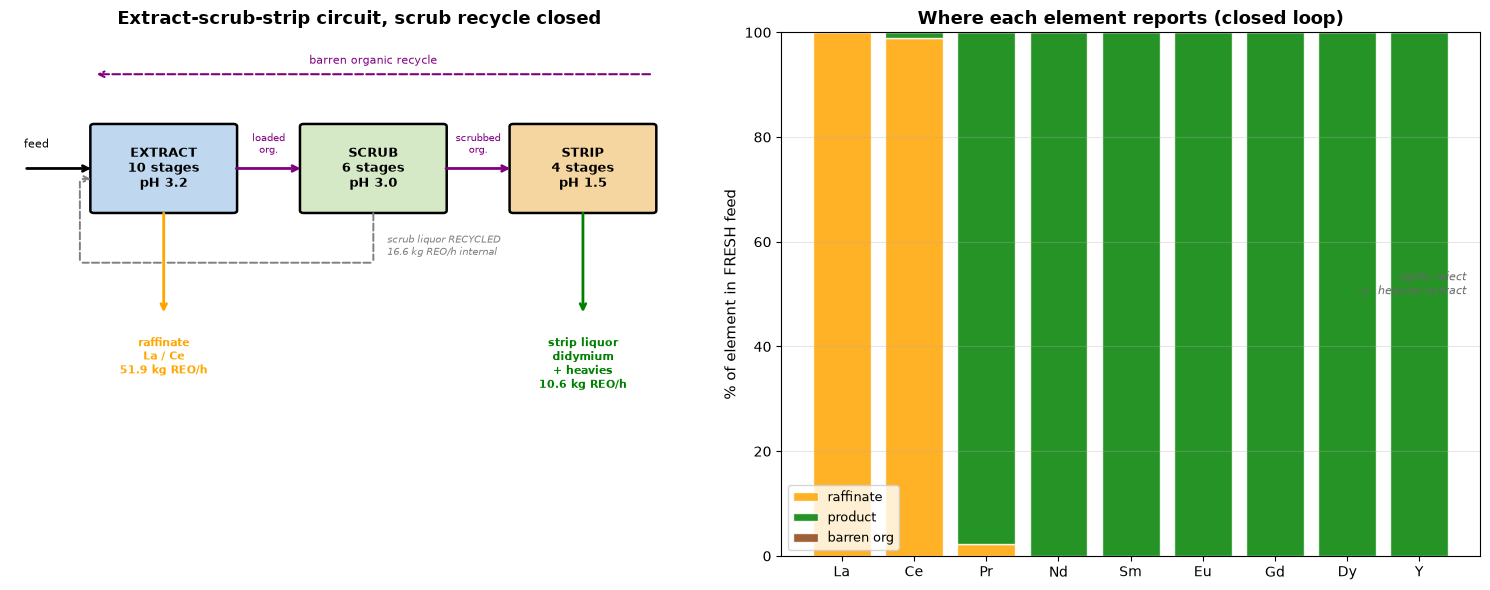

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ---- Left: block flow diagram, all four outlets -----------------------
ax1 = axes[0]
ax1.set_xlim(0, 10); ax1.set_ylim(0, 10); ax1.axis("off")
ax1.set_title("Extract-scrub-strip circuit, scrub recycle closed",
              fontsize=13, fontweight="bold")

def block(ax, x, y, w, h, label, color):
    ax.add_patch(mpatches.FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.05",
        facecolor=color, edgecolor="black", linewidth=1.8))
    ax.text(x + w / 2, y + h / 2, label, ha="center", va="center",
            fontsize=9, fontweight="bold")

block(ax1, 1.2, 6.6, 2.0, 1.6, f"EXTRACT\n{N_EXTRACTION} stages\npH {EXTRACTION_PH}", "#bfd8ef")
block(ax1, 4.2, 6.6, 2.0, 1.6, f"SCRUB\n{N_SCRUBBING} stages\npH {SCRUBBING_PH}", "#d6e9c6")
block(ax1, 7.2, 6.6, 2.0, 1.6, f"STRIP\n{N_STRIPPING} stages\npH {STRIPPING_PH}", "#f5d5a0")

for x0, x1 in ((3.2, 4.2), (6.2, 7.2)):
    ax1.annotate("", xy=(x1, 7.4), xytext=(x0, 7.4),
                 arrowprops=dict(arrowstyle="->", lw=2, color="purple"))
ax1.text(3.7, 7.7, "loaded\norg.", fontsize=7, ha="center", color="purple")
ax1.text(6.7, 7.7, "scrubbed\norg.", fontsize=7, ha="center", color="purple")

ax1.annotate("", xy=(1.2, 7.4), xytext=(0.2, 7.4),
             arrowprops=dict(arrowstyle="->", lw=2, color="black"))
ax1.text(0.2, 7.8, "feed", fontsize=8)

outlets = [
    (2.2, "raffinate\nLa / Ce", "orange", "raffinate"),
    (8.2, "strip liquor\ndidymium\n+ heavies", "green", "product"),
]
for x, label, color, key in outlets:
    ax1.annotate("", xy=(x, 4.6), xytext=(x, 6.6),
                 arrowprops=dict(arrowstyle="->", lw=2, color=color))
    reo = float(ree_oxide_mass_flow({e: streams[key].get(e, 0.0)
                                     for e in all_elements})) * 3600
    ax1.text(x, 4.2, f"{label}\n{reo:.1f} kg REO/h",
             fontsize=8, ha="center", va="top", color=color, fontweight="bold")

ax1.annotate("", xy=(1.2, 9.2), xytext=(9.2, 9.2),
             arrowprops=dict(arrowstyle="->", lw=1.5, color="purple", ls="--"))
ax1.text(5.2, 9.4, "barren organic recycle", fontsize=8,
         ha="center", color="purple")
# Scrub liquor recycle: down out of the scrubber, back to the extraction feed.
for xy, xytext in (((5.2, 5.6), (5.2, 6.6)), ((2.2, 5.6), (5.2, 5.6)),
                   ((1.0, 7.2), (1.0, 5.6)), ((1.0, 5.6), (2.2, 5.6))):
    ax1.annotate("", xy=xy, xytext=xytext,
                 arrowprops=dict(arrowstyle="-", lw=1.4, color="grey", ls="--"))
ax1.annotate("", xy=(1.2, 7.2), xytext=(1.0, 7.2),
             arrowprops=dict(arrowstyle="->", lw=1.4, color="grey", ls="--"))
_rec_reo = float(ree_oxide_mass_flow(recycle)) * 3600
ax1.text(5.4, 5.75, f"scrub liquor RECYCLED\n{_rec_reo:.1f} kg REO/h internal",
         fontsize=7, color="grey", style="italic")

# ---- Right: where each element reports, stacked ------------------------
ax2 = axes[1]
order = list(all_elements)
bottom = np.zeros(len(order))
colors = {"raffinate": "orange", "product": "green",
          "barren org": "saddlebrown"}
for key, flows in streams.items():
    frac = np.array([float(flows.get(e, 0.0)) / float(feed_f[e]) * 100
                     for e in order])
    ax2.bar(order, frac, bottom=bottom, label=key,
            color=colors[key], alpha=0.85, edgecolor="white")
    bottom += frac
ax2.set_ylabel("% of element in FRESH feed", fontsize=11)
ax2.set_ylim(0, 100)
ax2.set_title("Where each element reports (closed loop)",
              fontsize=13, fontweight="bold")
ax2.legend(fontsize=9, loc="lower left")
ax2.grid(axis="y", alpha=0.3)
ax2.text(0.98, 0.5, "lights reject\n->  heavies extract", transform=ax2.transAxes,
         fontsize=8, ha="right", style="italic", color="dimgrey")

plt.tight_layout()
plt.show()

## 6. Cost structure

Two different pedigrees meet in this section, and they must not be read the same
way.

**The capital cost has a source.** `estimate_capex` does not build a factored
estimate from a per-stage equipment price. It takes its *level* from a project
cost somebody published, and moves that to this plant's capacity by the 0.6
power law and to this year by a CEPCI ratio. `capex_basis(scope)` names the
project, its citation key in `sources.yaml`, what the figure enclosed, and the
accuracy that follows. Three anchors are available and **they differ by more
than a factor of ten at the same capacity** — not because they disagree about
one plant, but because they draw the battery limits around different amounts of
plant:

| `scope` | Anchor | What the dollar figure enclosed |
|---|---|---|
| `sx_retrofit` | Energy Fuels White Mesa Phase 1 — **$16 M as-built**, 4,500 t/yr REO feed | Mixer-settler trains, their tanks, pumps, piping, instruments and installation. Buildings, power, utilities, effluent treatment and the licence were already there. |
| `separation_plant` | Avalon Nechalacho at Geismar, LA — **US$302 M**, 10,000 t/yr separated REO, 2012 prefeasibility | A standalone refinery: the cascade *plus* reagent handling, precipitation and calcination, effluent treatment, civils, electrical, utilities, engineering and contingency. No mine, no concentrator, no cracking plant. |
| `integrated` | Energy Fuels Phase 2 — **$410 M**, AACE Class 3 bankable study, ~7,554 t/yr separated products | The above *plus* monazite cracking and leaching. |

**Nothing else in this section has a source.** The oxide prices are `ESTIMATED`
in the sense of section 0, the payability below is an outright assumption about
a commercial negotiation, and every OPEX unit rate is a placeholder. So the
capital line can be argued about with a filing in hand; the revenue and
operating lines cannot.

### Which scope this notebook uses, and why

`separation_plant`. The circuit simulated above starts from a leach liquor and
ends at two liquors, so on equipment alone `sx_retrofit` is the closer
description — and it is reported below as the brownfield bracket, which is the
right number if this cascade were dropped into a mill that already exists.

But it is the wrong number for a *project*. A facility that takes leach liquor
and ships concentrate still needs a building to stand in, power, steam, cooling
water, reagent storage, effluent treatment, a laboratory and a licence, and the
retrofit anchor got all of those free from an operating uranium mill. Charging
the greenfield figure is the conservative reading, and a section whose next step
is a payback period should take the conservative reading.

### Capacity basis, which the anchors do not agree on

`sx_retrofit` is quoted per tonne of REO **fed**; the other two per tonne of
**separated product**. For a full separation train those nearly coincide, and
Avalon's release says by how much: overall plant recovery 98 %, so its
10,000 t/yr of product came from 10,200 t/yr of feed and the basis does not
matter for that anchor. For this circuit they do not: 500 t/yr of REO goes in and
about 85 t/yr leaves in the didymium liquor, because the La and the Ce are
rejected rather than separated. The plant is sized by what flows through it, so
the feed tonnage is what is scaled here. Scaling the *product* tonnage against
these anchors instead would undersize the plant by a factor of about six.

### And scaling one project is a Class 5 method

Capacity-factoring a single data point is AACE 18R-97 Class 5 — the widest
class there is — however well defined the anchor was. Avalon's own figure was
Class 4, and the study claims ±25 %; what comes out of the power law below
is about −50 %/+100 %, and that is the range to quote. `capex_basis` reports both so the
two cannot be confused.

### Payability, not "% of oxide price"

Neither of these streams is a finished oxide, so neither sells at the oxide
price. Two rules keep that honest:

1. Value the **contained oxide**, via `ree_oxide_mass_flow`, at the oxide prices
   the database quotes — not the metal mass, for the reason given in section 1.
2. Make the discount an explicit, named **payability** — the fraction of
   contained value a buyer actually pays for an unfinished concentrate — and
   vary it, because the answer is far more sensitive to it than to anything in
   the flowsheet. A bare "80 % of price" buried in a revenue line is the same
   assumption with the uncertainty hidden.

The two payabilities differ sharply, and not arbitrarily. A didymium-rich strip
liquor goes to a market that wants it. A La/Ce carbonate goes to a market in
structural surplus: La and Ce are co-produced with everything else in far
greater quantity than catalyst and polishing demand absorbs, which is why their
oxide prices are $5 and $2/kg in the first place. Paying 10 % of a $2/kg oxide
is close to paying nothing, and that is the honest description of this stream.

In [10]:
pricing = REEPricing()

# Payability: fraction of contained-oxide value a buyer pays for an
# unfinished concentrate. ASSUMPTIONS, stated as such -- not sourced.
PAYABILITY = {
    "product": 0.55,     # didymium-rich mixed strip liquor, wanted market
    "raffinate": 0.10,   # La/Ce carbonate, market in structural surplus
    "barren org": 0.0,   # regenerated solvent, not a product
}

def stream_value(flows, payability):
    """Annual contained-oxide value of a stream, USD/year."""
    rows, total = [], 0.0
    for elem in all_elements:
        mol_s = float(flows.get(elem, 0.0))
        if mol_s <= 0.0:
            continue
        kg_reo_yr = float(ree_oxide_mass_flow({elem: mol_s})) * 3600 * HOURS_PER_YEAR
        price = pricing.get_price(elem, "99%", "oxide")
        value = kg_reo_yr * price * payability
        total += value
        rows.append((elem, kg_reo_yr, price, value))
    return rows, total

print("Contained-oxide value by stream")
print("=" * 72)
revenue_by_stream = {}
for name in ("product", "raffinate"):
    pay = PAYABILITY[name]
    rows, subtotal = stream_value(streams[name], pay)
    revenue_by_stream[name] = subtotal
    print(f"\n{name.upper()}  (payability {pay:.0%} of contained oxide)")
    print(f"  {'el':>4} {'kg REO/yr':>11} {'$/kg oxide':>11} {'$k/yr':>10}")
    for elem, kg, price, value in sorted(rows, key=lambda r: -r[3]):
        if kg < 1:
            continue
        print(f"  {elem:>4} {kg:>11,.0f} {price:>11,.0f} {value / 1e3:>10,.1f}")
    print(f"  subtotal: ${subtotal / 1e6:.2f} M/year")

total_revenue = sum(revenue_by_stream.values())
print("\n" + "=" * 72)
print(f"TOTAL REVENUE: ${total_revenue / 1e6:.2f} M/year   "
      f"[every price ESTIMATED; payability assumed]")
_rev_frac = revenue_by_stream["product"] / total_revenue * 100
_prod_reo = float(ree_oxide_mass_flow(
    {e: streams["product"].get(e, 0.0) for e in all_elements}))
_mass_frac = _prod_reo / reo_check * 100
print(f"\nThe strip liquor is {_rev_frac:.0f}% of revenue from "
      f"{_mass_frac:.0f}% of the contained REO mass.")
print(f"The raffinate is {100 - _mass_frac:.0f}% of the mass and "
      f"{100 - _rev_frac:.0f}% of the revenue: half this ore is")
print("cerium, and cerium is very nearly worthless.")

Contained-oxide value by stream

PRODUCT  (payability 55% of contained oxide)
    el   kg REO/yr  $/kg oxide      $k/yr
    Nd      55,983         120    3,694.9
    Pr      20,044          85      937.1
    Sm       4,499          15       37.1
    Dy         150         450       37.1
    Gd       1,000          55       30.2
    Eu         500          35        9.6
     Y         500          35        9.6
    Ce       2,503           2        2.8
  subtotal: $4.76 M/year

RAFFINATE  (payability 10% of contained oxide)
    el   kg REO/yr  $/kg oxide      $k/yr
    La     168,949           5       84.5
    Ce     245,423           2       49.1
    Pr         450          85        3.8
  subtotal: $0.14 M/year

TOTAL REVENUE: $4.90 M/year   [every price ESTIMATED; payability assumed]

The strip liquor is 97% of revenue from 17% of the contained REO mass.
The raffinate is 83% of the mass and 3% of the revenue: half this ore is
cerium, and cerium is very nearly worthless.


In [11]:
annual_reo_tonnes = reo_check * 3600 * HOURS_PER_YEAR / 1000

# Battery limits, chosen deliberately: a standalone facility, not a cascade
# bolted into someone else's licensed mill. See the discussion above.
SCOPE = "separation_plant"
basis = capex_basis(SCOPE)

print(f"Capital cost basis: {basis['source']}  (sources.yaml)")
print("=" * 72)
print(f"  {basis['description']}")
print(f"  Disclosed        ${basis['capex_usd'] / 1e6:,.0f} M for "
      f"{basis['capacity_tpy']:,.0f} t/yr {basis['capacity_basis']}, "
      f"{basis['year']} basis")
print(f"  Anchor class     {basis['aace_class']}  "
      f"({basis['accuracy'][0]:+.0%} / {basis['accuracy'][1]:+.0%})")
print(f"  This estimate    {basis['derived_class']}  "
      f"({basis['derived_accuracy'][0]:+.0%} / "
      f"{basis['derived_accuracy'][1]:+.0%})")
print("  Includes:")
for line in basis["includes"]:
    print(f"    + {line}")
print("  Excludes:")
for line in basis["excludes"]:
    print(f"    - {line}")

# Costed on the SAME stage counts that were simulated -- N_EXTRACTION and
# friends are declared once, in section 3, and reused here. No
# n_stages_reference is passed: no anchor publishes a stage count, so there is
# no base case to move away from, and inventing one would put an unsourced
# number into the level rather than into the shape.
capex = estimate_capex(
    annual_ree_tonnes=annual_reo_tonnes,
    n_stages_extraction=N_EXTRACTION,
    n_stages_scrubbing=N_SCRUBBING,
    n_stages_stripping=N_STRIPPING,
    include_precipitation=False,   # selling concentrates, not finished oxides
    include_ce_removal=False,
    year=2024,
    scope=SCOPE,
)
brownfield = estimate_capex(
    annual_ree_tonnes=annual_reo_tonnes,
    n_stages_extraction=N_EXTRACTION,
    n_stages_scrubbing=N_SCRUBBING,
    n_stages_stripping=N_STRIPPING,
    include_precipitation=False,
    include_ce_removal=False,
    year=2024,
    scope="sx_retrofit",
)

print(f"\nPlant basis: {annual_reo_tonnes:.0f} t REO/year FED, "
      f"{N_EXTRACTION + N_SCRUBBING + N_STRIPPING} mixer-settler stages")
print(f"Capacity ratio to the anchor: "
      f"{annual_reo_tonnes / basis['capacity_tpy']:.3f}, "
      f"scaled at the 0.6 power")

print("\nCapital cost")
print("=" * 72)
for item, cost in capex.items():
    if cost > 0 and item != "total":
        print(f"  {item:<22s} ${cost / 1e6:>8,.1f} M")
print(f"  {'TOTAL':<22s} ${capex['total'] / 1e6:>8,.1f} M")
# The rows are a conventional split of an anchored total; only the total is
# anchored. If they ever stop summing to it, the split is what is broken.
assert abs(sum(v for k, v in capex.items() if k != "total")
           - capex["total"]) < 1.0

_lo, _hi = basis["derived_accuracy"]
print(f"\n  Range at the derived estimate class: "
      f"${capex['total'] * (1 + _lo) / 1e6:,.0f} M to "
      f"${capex['total'] * (1 + _hi) / 1e6:,.0f} M")
print(f"  Brownfield bracket ({basis['scope']} -> sx_retrofit): "
      f"${brownfield['total'] / 1e6:,.1f} M")
print(f"  -> the two brackets differ by "
      f"{capex['total'] / brownfield['total']:.0f}x at the same capacity, "
      f"same year,")
print("     same stages. That factor is battery limits, not disagreement.")

# include_precipitation must match the CAPEX flag: a circuit costed without a
# precipitation section should not be paying for precipitant. The assertion
# below is what keeps the two flags from drifting apart.
opex = estimate_opex(
    annual_ree_tonnes=annual_reo_tonnes,
    capex=capex["total"],
    extractant="PC88A",
    include_precipitation=False,
)
assert opex["precipitant"] == 0.0, "OPEX charges for a section we did not build"

print("\nOperating cost  [every unit rate ESTIMATED -- no source]")
print("=" * 72)
for item, cost in sorted(opex.items(), key=lambda kv: -kv[1]):
    if item != "total":
        print(f"  {item:<22s} ${cost / 1e6:>8,.2f} M/year")
print(f"  {'TOTAL':<22s} ${opex['total'] / 1e6:>8,.2f} M/year")
_top = max((k for k in opex if k != "total"), key=lambda k: opex[k])
print(f"\n  Largest line: {_top} (${opex[_top] / 1e6:.2f} M/yr, "
      f"{opex[_top] / opex['total'] * 100:.0f}% of OPEX)")
print(f"""
  Maintenance is charged at 3% of CAPEX, so on a greenfield basis it is the
  largest operating line -- ${opex['maintenance'] / 1e6:.2f} M/yr against
  ${opex['labor'] / 1e6:.2f} M/yr of labor. That is not an artifact of the
  anchor: a capital-heavy plant has a capital-heavy cost of ownership, and it
  is the first thing the brownfield bracket buys you out of.

  Note on the labor line: estimate_opex takes n_operators as TOTAL operating
  headcount, not headcount per shift -- the two readings differ by the number
  of crews. Six people covering 8000 h/year is a thin crew; staffing a
  continuous plant properly is about four rotating crews, so pass
  n_operators=24 for that. It would add ~${opex['labor'] * 3 / 1e6:.1f} M/yr.""")

# The one published operating rate any of the anchors gives, as a cross-check.
# Avalon: US$5,634 per tonne of separated REO at 10,000 t/yr, covering labour,
# supplies, reagents and maintenance -- no capital charge, no feed cost. Same
# exclusions as the total above, which is what makes the comparison legitimate.
from difflow_ree.economics.costs import CEPCI

AVALON_OPEX_PER_T = 5634.0          # sources.yaml:AVALON_GEISMAR, 2012 USD
_here = opex["total"] / annual_reo_tonnes
_avalon_2024 = AVALON_OPEX_PER_T * CEPCI[2024] / CEPCI[2012]
print(f"""
  Cross-check, and the only one available: Avalon's study puts operating cost
  at ${AVALON_OPEX_PER_T:,.0f}/t of REO at 10,000 t/yr, ${_avalon_2024:,.0f}/t in
  2024 dollars on the same CEPCI ratio used for the capital. This circuit comes
  out at ${_here:,.0f}/t of REO fed -- {_here / _avalon_2024:.1f}x that rate, at
  1/20th the capacity.

  A factor of {_here / _avalon_2024:.1f} for a plant 20x smaller is the right
  sign and a believable size: labor and maintenance do not scale down with
  throughput. It does not validate any single unit rate above -- Avalon's feed
  and product slate are different, and its figure is a study estimate too --
  but it is the first number in this section that came from outside difflow,
  and the total is not off by an order of magnitude.""")

Capital cost basis: AVALON_GEISMAR  (sources.yaml)
  Avalon Rare Metals' proposed Nechalacho separation plant and refinery at Geismar, Louisiana: a standalone separation refinery on a greenfield site, fed with mixed concentrate from elsewhere. Prefeasibility study by SNC-Lavalin.
  Disclosed        $302 M for 10,000 t/yr separated REO, 2012 basis
  Anchor class     AACE Class 4 (prefeasibility), +/-25% claimed  (-25% / +25%)
  This estimate    AACE Class 5 (capacity-factored from one project)  (-50% / +100%)
  Includes:
    + "a complete separation plant facility; infrastructure, utilities and ancillary services; indirect costs; and contingency"
    + the full solvent-extraction house -- over 1,000 mixer-settlers, disclosed at 33% of the total, US$101 million
    + reagent receipt, storage and make-up
    + precipitation and calcination to saleable oxide
    + buildings, civils, electrical and utilities
    + engineering, offsites and contingency
  Excludes:
    - the mine and concentr

In [12]:
profit = calculate_profit(
    revenue=total_revenue,
    opex=opex["total"],
    capex=capex["total"],
)

print("Margin structure -- NOT a project evaluation")
print("=" * 72)
print(f"  Revenue        ${profit['revenue'] / 1e6:>10,.2f} M/year")
print(f"  OPEX           ${profit['opex'] / 1e6:>10,.2f} M/year")
print(f"  EBITDA         ${profit['ebitda'] / 1e6:>10,.2f} M/year")
print(f"  Depreciation   ${profit['depreciation'] / 1e6:>10,.2f} M/year")
print(f"  Net income     ${profit['net_income'] / 1e6:>10,.2f} M/year")
print(f"  CAPEX          ${capex['total'] / 1e6:>10,.2f} M")
payback = float(profit["payback_years"])
print(f"  Payback        {payback:>10.1f} years" if np.isfinite(payback)
      else "  Payback              never (cash flow <= 0)")
print(f"  ROI            {profit['roi'] * 100:>10.1f}%")

print("""
No verdict is printed here -- no "payback acceptable", no go/no-go. The
capital line is anchored to a disclosed project cost, but it is a Class 5
scaling of it, and everything it is compared against -- the prices, the
payability, every OPEX unit rate -- carries no identified source at all. A
sign test on those inputs carries no information about a project.

What IS supportable from the lines above:
""")
print(f"  * Depreciation alone is ${profit['depreciation'] / 1e6:.1f} M/yr "
      f"against ${total_revenue / 1e6:.1f} M/yr of revenue.")
print(f"    Straight-line over 10 years on ${capex['total'] / 1e6:.0f} M of "
      f"capital costs "
      f"{profit['depreciation'] / total_revenue:.1f}x")
print("    everything this plant sells. No operating improvement closes that,")
print("    and no error bar on the anchor closes it either: the low end of the")
print(f"    Class 5 range, ${capex['total'] * (1 + _lo) / 1e6:.0f} M, still "
      f"depreciates at "
      f"${capex['total'] * (1 + _lo) / 10 / 1e6:.1f} M/yr.")
print(f"  * EBITDA is {'positive' if profit['ebitda'] > 0 else 'negative'} "
      f"before capital charge, and section 7 shows how little")
print("    it takes to flip, because it depends on numbers nobody sourced.")
print(f"  * The largest operating line is {_top}, at "
      f"{opex[_top] / opex['total'] * 100:.0f}% of OPEX -- and it is a flat 3%")
print(f"    of CAPEX, so that fraction of the OPEX above is the capital number")
print(f"    wearing a different hat rather than an independent estimate of what")
print(f"    running this plant costs. Labor, the largest line that is genuinely")
print(f"    an operating cost, is ${opex['labor'] / 1e6:.2f} M/yr on a "
      f"headcount of six.")
print(f"  * On the brownfield bracket instead -- "
      f"${brownfield['total'] / 1e6:.1f} M, this cascade inside")
print("    an existing licensed mill -- depreciation is "
      f"${brownfield['total'] / 10 / 1e6:.2f} M/yr and the sign flips.")
print("    THAT is the structural result: at 500 t/yr of a feed that is 83%")
print("    La+Ce, the answer is decided by whether the project has to pay for")
print("    a site, not by anything in the flowsheet.")

Margin structure -- NOT a project evaluation
  Revenue        $      4.90 M/year
  OPEX           $      5.58 M/year
  EBITDA         $     -0.69 M/year
  Depreciation   $      6.38 M/year
  Net income     $     -7.07 M/year
  CAPEX          $     63.82 M
  Payback              never (cash flow <= 0)
  ROI                 -11.1%

No verdict is printed here -- no "payback acceptable", no go/no-go. The
capital line is anchored to a disclosed project cost, but it is a Class 5
scaling of it, and everything it is compared against -- the prices, the
payability, every OPEX unit rate -- carries no identified source at all. A
sign test on those inputs carries no information about a project.

What IS supportable from the lines above:

  * Depreciation alone is $6.4 M/yr against $4.9 M/yr of revenue.
    Straight-line over 10 years on $64 M of capital costs 1.3x
    everything this plant sells. No operating improvement closes that,
    and no error bar on the anchor closes it either: the low end 

## 7. What the answer actually depends on

The flowsheet has many knobs and the economics have two. Vary both and see which
one matters.

Payability is the assumption with no source at all — a guess about a commercial
negotiation, sitting in front of prices that are themselves only indicative. Nd
price is the number a technoeconomic study would normally sensitise. Sweep both
over ranges nobody can rule out and compare the swing to the base EBITDA — the
quantity a technoeconomic summary would be tempted to render a verdict on.

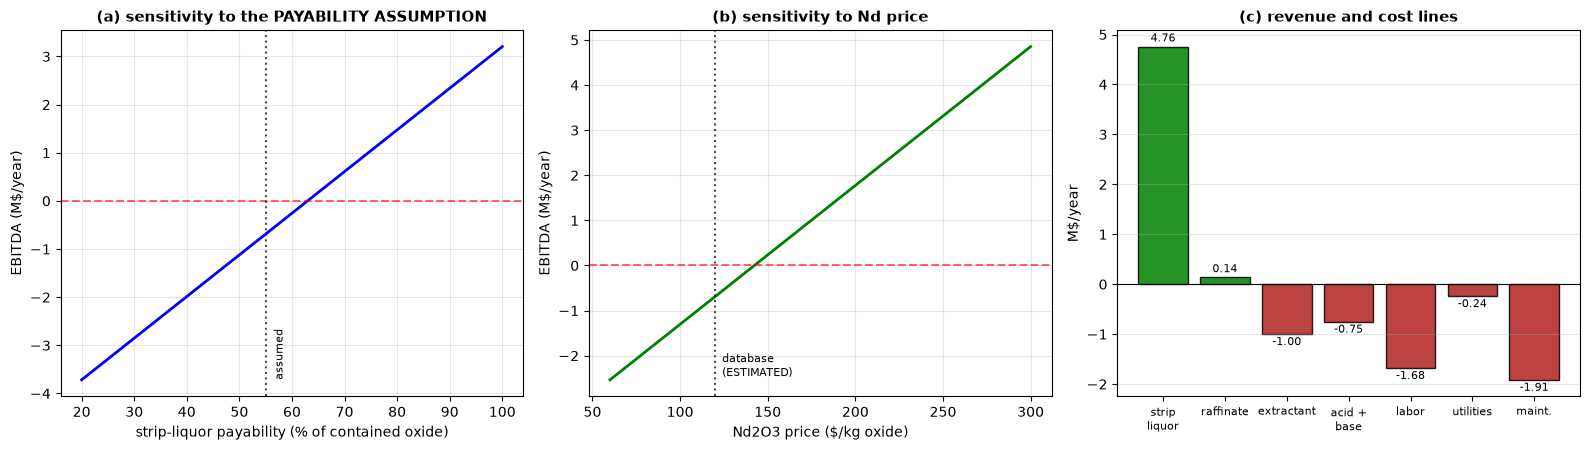

Base EBITDA at the assumed inputs:        $-0.69 M/year
EBITDA span over payability 20-100%:      $6.92 M/year  (10x the base)
EBITDA span over Nd price $60-300/kg:     $7.39 M/year  (11x the base)

The two assumptions move EBITDA by comparable amounts, and each span is several
times the magnitude of the base EBITDA (10.0x and 10.7x). Panel (a) crosses zero at a
payability of 63%, and panel (b) at an Nd price of $142/kg. Both crossings
sit inside the range of the guess -- neither is an extreme corner of it.

That is the result: the sign of the answer is set by two numbers nobody
sourced, so the sign is not a finding. Neither is any conclusion drawn from
it -- which is why section 6 prints no verdict.


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# ---- (a) payability sweep ---------------------------------------------
ax = axes[0]
pays = np.linspace(0.2, 1.0, 161)
ebitda_pay = []
for pay in pays:
    _, prod_v = stream_value(streams["product"], pay)
    _, raff_v = stream_value(streams["raffinate"], PAYABILITY["raffinate"])
    pr = calculate_profit(revenue=prod_v + raff_v, opex=opex["total"],
                          capex=capex["total"])
    ebitda_pay.append(float(pr["ebitda"]) / 1e6)
ax.plot(pays * 100, ebitda_pay, "b-", lw=2)
ax.axhline(0, color="r", ls="--", alpha=0.6)
ax.axvline(PAYABILITY["product"] * 100, color="k", ls=":", alpha=0.7)
ax.text(PAYABILITY["product"] * 100 + 1.5, min(ebitda_pay),
        "assumed", fontsize=8, rotation=90, va="bottom")
ax.set_xlabel("strip-liquor payability (% of contained oxide)")
ax.set_ylabel("EBITDA (M$/year)")
ax.set_title("(a) sensitivity to the PAYABILITY ASSUMPTION",
             fontsize=11, fontweight="bold")
ax.grid(alpha=0.3)

# ---- (b) Nd price sweep -----------------------------------------------
ax = axes[1]
nd_kg_yr = float(ree_oxide_mass_flow(
    {"Nd": float(streams["product"].get("Nd", 0.0))})) * 3600 * HOURS_PER_YEAR
base_nd_price = pricing.get_price("Nd", "99%", "oxide")
nd_prices = np.linspace(60.0, 300.0, 161)
ebitda_nd = []
for nd_price in nd_prices:
    revenue_adj = total_revenue + nd_kg_yr * PAYABILITY["product"] * (
        nd_price - base_nd_price)
    pr = calculate_profit(revenue=revenue_adj, opex=opex["total"],
                          capex=capex["total"])
    ebitda_nd.append(float(pr["ebitda"]) / 1e6)
ax.plot(nd_prices, ebitda_nd, "g-", lw=2)
ax.axhline(0, color="r", ls="--", alpha=0.6)
ax.axvline(base_nd_price, color="k", ls=":", alpha=0.7)
ax.text(base_nd_price + 4, min(ebitda_nd), "database\n(ESTIMATED)",
        fontsize=8, va="bottom")
ax.set_xlabel("Nd2O3 price ($/kg oxide)")
ax.set_ylabel("EBITDA (M$/year)")
ax.set_title("(b) sensitivity to Nd price", fontsize=11, fontweight="bold")
ax.grid(alpha=0.3)

# ---- (c) cost/revenue breakdown ---------------------------------------
ax = axes[2]
labels = ["strip\nliquor", "raffinate", "extractant", "acid +\nbase",
          "labor", "utilities", "maint."]
values = [
    revenue_by_stream["product"] / 1e6,
    revenue_by_stream["raffinate"] / 1e6,
    -opex["extractant"] / 1e6,
    -(opex["acid"] + opex["base"]) / 1e6,
    -opex["labor"] / 1e6,
    -opex["utilities"] / 1e6,
    -opex["maintenance"] / 1e6,
]
ax.bar(labels, values,
       color=["green" if v > 0 else "firebrick" for v in values],
       alpha=0.85, edgecolor="black")
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("M$/year")
ax.set_title("(c) revenue and cost lines", fontsize=11, fontweight="bold")
ax.tick_params(axis="x", labelsize=8)
ax.grid(axis="y", alpha=0.3)
for i, v in enumerate(values):
    ax.text(i, v + (0.05 if v >= 0 else -0.05), f"{v:.2f}",
            ha="center", va="bottom" if v >= 0 else "top", fontsize=8)

plt.tight_layout()
plt.show()

_span_pay = max(ebitda_pay) - min(ebitda_pay)
_span_nd = max(ebitda_nd) - min(ebitda_nd)
_base = float(profit["ebitda"]) / 1e6
print(f"Base EBITDA at the assumed inputs:        ${_base:.2f} M/year")
print(f"EBITDA span over payability 20-100%:      ${_span_pay:.2f} M/year"
      f"  ({_span_pay / abs(_base):.0f}x the base)")
print(f"EBITDA span over Nd price $60-300/kg:     ${_span_nd:.2f} M/year"
      f"  ({_span_nd / abs(_base):.0f}x the base)")
_pay_cross = np.interp(0.0, ebitda_pay, pays * 100)
_nd_cross = np.interp(0.0, ebitda_nd, nd_prices)
print(f"""
The two assumptions move EBITDA by comparable amounts, and each span is several
times the magnitude of the base EBITDA ({_span_pay / abs(_base):.1f}x and {_span_nd / abs(_base):.1f}x). Panel (a) crosses zero at a
payability of {_pay_cross:.0f}%, and panel (b) at an Nd price of ${_nd_cross:.0f}/kg. Both crossings
sit inside the range of the guess -- neither is an extreme corner of it.

That is the result: the sign of the answer is set by two numbers nobody
sourced, so the sign is not a finding. Neither is any conclusion drawn from
it -- which is why section 6 prints no verdict.""")

## 8. Break-even, computed safely

The question "what Nd price would break even?" is a division by the Nd
production rate, and that division is a trap. A circuit that is barely
extracting does not produce zero — it produces something like `1e-16` kg/year,
which is *positive*, passes a guard written as `if nd_mass_yr > 0`, prints as
`0` under `:.0f`, and as a divisor yields a break-even price with twenty-two
digits in it. A second guard on the result being positive waves that through
too, because it is positive.

A smaller epsilon is not the answer, because there is no absolute mass that is
meaningful independent of plant size. The test has to be on the thing the
division actually requires: that Nd recovery is a *physically meaningful*
fraction of the feed. A circuit recovering under a percent of its target
element has no break-even price, and the right output is to say so rather than
to compute one.

At this operating point there is a real Nd stream, so the guard is not exercised
by the run below. The cell after it deliberately runs the circuit *outside* the
fitted pH window, which is where that situation arises, and shows both
protections doing their jobs.

In [14]:
nd_feed_kg_yr = float(ree_oxide_mass_flow(
    {"Nd": float(feed_f["Nd"])})) * 3600 * HOURS_PER_YEAR
nd_recovery = nd_kg_yr / nd_feed_kg_yr

# A break-even price is only defined if the stream we would sell exists.
# Threshold is on RECOVERY -- a dimensionless, physical quantity -- not on
# an absolute mass being "> 0", which 1e-16 satisfies.
MIN_RECOVERY_FOR_BREAKEVEN = 0.01

required_revenue = opex["total"] + float(profit["depreciation"])
revenue_gap = required_revenue - total_revenue

print("Break-even analysis")
print("=" * 66)
print(f"  Current revenue          ${total_revenue / 1e6:>8.2f} M/year")
print(f"  Required (OPEX + depr.)  ${required_revenue / 1e6:>8.2f} M/year")
print(f"  Gap                      ${revenue_gap / 1e6:>8.2f} M/year")
print(f"\n  Nd in feed               {nd_feed_kg_yr:>8,.0f} kg Nd2O3/year")
print(f"  Nd in strip liquor       {nd_kg_yr:>8,.0f} kg Nd2O3/year "
      f"({nd_recovery:.1%} recovery)")

if nd_recovery < MIN_RECOVERY_FOR_BREAKEVEN:
    print(f"""
  Nd recovery is {nd_recovery:.2e}, below the {MIN_RECOVERY_FOR_BREAKEVEN:.0%} threshold.
  NO BREAK-EVEN Nd PRICE EXISTS: there is no Nd product to reprice. The
  circuit is not extracting -- fix the operating point before asking an
  economic question about it.""")
elif revenue_gap <= 0:
    print(f"""
  Revenue already exceeds OPEX + depreciation at the assumed payability, so
  no Nd price increase is required. Note what that rests on: see section 7.""")
else:
    nd_revenue_per_dollar = nd_kg_yr * PAYABILITY["product"]
    breakeven_nd_price = base_nd_price + revenue_gap / nd_revenue_per_dollar
    print(f"""
  Nd price in database     ${base_nd_price:>8,.0f}/kg Nd2O3  [ESTIMATED]
  Realised, at {PAYABILITY['product']:.0%} pay      ${base_nd_price * PAYABILITY['product']:>8,.0f}/kg
  Break-even Nd price      ${breakeven_nd_price:>8,.0f}/kg Nd2O3
  -> a {(breakeven_nd_price / base_nd_price - 1) * 100:.0f}% increase over the database price.""")
    if breakeven_nd_price > 10 * base_nd_price:
        print("\n  That is more than 10x the reference price. Read it as "
              "'not at any\n  plausible price', not as a forecast.")

print("\n" + "=" * 66)
print("Scale-up: does this get better with size?")
print("=" * 66)
print("  CAPEX and OPEX are re-estimated at each capacity rather than scaled")
print("  by hand -- same anchor, same 0.6 exponent, same scope -- and labor")
print("  stays at the same headcount, because n_operators is not a function")
print("  of throughput.")
_sweep = []
for scale in (1, 2, 5, 10, 20):
    scaled_tonnes = annual_reo_tonnes * scale
    scaled_capex = estimate_capex(
        annual_ree_tonnes=scaled_tonnes,
        n_stages_extraction=N_EXTRACTION,
        n_stages_scrubbing=N_SCRUBBING,
        n_stages_stripping=N_STRIPPING,
        include_precipitation=False, include_ce_removal=False,
        year=2024, scope=SCOPE,
    )["total"]
    scaled_opex = estimate_opex(
        annual_ree_tonnes=scaled_tonnes, capex=scaled_capex,
        extractant="PC88A", include_precipitation=False,
    )["total"]
    sp = calculate_profit(revenue=total_revenue * scale,
                          opex=scaled_opex, capex=scaled_capex)
    print(f"\n  {scale:>2}x  ({scaled_tonnes:>6,.0f} t REO/yr fed)"
          f"  revenue ${total_revenue * scale / 1e6:>6.1f}M"
          f"  OPEX ${scaled_opex / 1e6:>6.1f}M"
          f"  CAPEX ${scaled_capex / 1e6:>5.0f}M")
    print(f"      EBITDA ${sp['ebitda'] / 1e6:>6.1f}M"
          f"   net income ${sp['net_income'] / 1e6:>6.1f}M"
          f"   ROI {sp['roi'] * 100:>5.1f}%")
    _sweep.append((scaled_tonnes, float(sp["net_income"])))

# Interpolate the crossing rather than reading it off the nearest row: the
# rows are a factor of two apart and the anchor's own capacity sits between
# two of them.
_t = np.array([t for t, _ in _sweep])
_ni = np.array([n for _, n in _sweep])
_cross_t = float(np.interp(0.0, _ni, _t))
_anchor_t = capex_basis(SCOPE)["capacity_tpy"]
print(f"""
Net income crosses zero at about {_cross_t:,.0f} t REO/year, between the 10x and
20x rows. The anchor project was costed at {_anchor_t:,.0f} t/yr, so the crossing
lands just below the one capacity at which this arithmetic stops being an
extrapolation and becomes the disclosed figure restated in 2024 dollars.

Read that as the answer to a question rather than as a plan. The question is
what throughput a feed this dilute in payable metal needs in order to carry a
separation plant, and on these assumptions it is tens of thousands of tonnes a
year -- the scale at which bastnasite separation is actually done. The specific
crossing point is only as good as the payability behind it, so what carries is
the order of magnitude, not the number.""")

Break-even analysis
  Current revenue          $    4.90 M/year
  Required (OPEX + depr.)  $   11.97 M/year
  Gap                      $    7.07 M/year

  Nd in feed                 55,983 kg Nd2O3/year
  Nd in strip liquor         55,983 kg Nd2O3/year (100.0% recovery)

  Nd price in database     $     120/kg Nd2O3  [ESTIMATED]
  Realised, at 55% pay      $      66/kg
  Break-even Nd price      $     350/kg Nd2O3
  -> a 191% increase over the database price.

Scale-up: does this get better with size?
  CAPEX and OPEX are re-estimated at each capacity rather than scaled
  by hand -- same anchor, same 0.6 exponent, same scope -- and labor
  stays at the same headcount, because n_operators is not a function
  of throughput.

   1x  (   500 t REO/yr fed)  revenue $   4.9M  OPEX $   5.6M  CAPEX $   64M
      EBITDA $  -0.7M   net income $  -7.1M   ROI -11.1%

   2x  ( 1,000 t REO/yr fed)  revenue $   9.8M  OPEX $   8.5M  CAPEX $   97M
      EBITDA $   1.3M   net income $  -8.4M   ROI  -8.7

In [15]:
# What the two protections actually protect against: run the same circuit
# outside the fitted pH window, where D collapses and the product vanishes.
OUTSIDE_WINDOW = dict(extraction_pH=1.5, scrubbing_pH=1.0, stripping_pH=0.3,
                      n_extraction_stages=8, n_scrubbing_stages=4,
                      n_stripping_stages=4, solvent_to_feed_ratio=2.0)

bad_params = ExtractScrubStripParams(
    extractant="PC88A", elements=all_elements,
    target_elements=("Pr", "Nd", "Sm", "Gd", "Dy"),
    scrub_to_solvent_ratio=0.15, strip_to_solvent_ratio=0.3, **OUTSIDE_WINDOW,
)

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    bad_results = ExtractScrubStripCircuit(bad_params)(bastnasite_feed, T=T_OP)
msgs = sorted({str(w.message) for w in caught
               if "validity range" in str(w.message)})

print("1. The correlation reports that it is being extrapolated.")
print("   Two of these three pH values sit below PC88A's fitted window:")
for m in msgs:
    print("     - " + m.split(". ")[0] + ".")
assert msgs, "expected the validity check to fire outside the window"

bad_prod = get_flows(bad_results["product"])
bad_nd_mol_s = float(bad_prod.get("Nd", 0.0))
bad_nd_kg_yr = float(ree_oxide_mass_flow({"Nd": bad_nd_mol_s})) * 3600 * HOURS_PER_YEAR
bad_recovery = bad_nd_kg_yr / nd_feed_kg_yr

print(f"""
2. What those conditions actually produce:
     Nd in product   {bad_nd_mol_s:.3e} mol/s
                     {bad_nd_kg_yr:.3e} kg Nd2O3/year
     Nd recovery     {bad_recovery:.3e}   (formats as "{bad_nd_kg_yr:.0f} kg/year")

   Positive, so `if nd_mass_yr > 0` would pass. Prints as 0, so a table of
   results looks merely unprofitable rather than broken. Used as a divisor:""")
print(f"     gap / nd_mass_yr  ->  ${1e6 / bad_nd_kg_yr:,.0f}/kg per $1M of gap")

print("\n3. The recovery guard, tested on the same quantity:")
if bad_recovery < MIN_RECOVERY_FOR_BREAKEVEN:
    print(f"     recovery {bad_recovery:.2e} < threshold "
          f"{MIN_RECOVERY_FOR_BREAKEVEN:.0%}  ->  REFUSED, no division performed.")
else:
    print("     guard did not fire -- the assertion below catches that")
assert bad_recovery < MIN_RECOVERY_FOR_BREAKEVEN

print("""
The threshold is on recovery -- dimensionless, physical, and independent of
plant size -- so it cannot be satisfied by a number that is merely positive.
The two protections are complementary: the first says the physics is being
extrapolated, the second refuses to build an economic conclusion on top of it.""")

1. The correlation reports that it is being extrapolated.
   Two of these three pH values sit below PC88A's fitted window:
     - pH minimum 0.3 is outside the validity range of the 'PC88A' pH correlation ([1.5, 5.5]) (#262).
     - pH minimum 1 is outside the validity range of the 'PC88A' pH correlation ([1.5, 5.5]) (#262).

2. What those conditions actually produce:
     Nd in product   1.063e-22 mol/s
                     5.149e-16 kg Nd2O3/year
     Nd recovery     9.198e-21   (formats as "0 kg/year")

   Positive, so `if nd_mass_yr > 0` would pass. Prints as 0, so a table of
   results looks merely unprofitable rather than broken. Used as a divisor:
     gap / nd_mass_yr  ->  $1,941,984,952,224,833,077,248/kg per $1M of gap

3. The recovery guard, tested on the same quantity:
     recovery 9.20e-21 < threshold 1%  ->  REFUSED, no division performed.

The threshold is on recovery -- dimensionless, physical, and independent of
plant size -- so it cannot be satisfied by a number that

## Summary

### What was built

A single PC88A extract-scrub-strip circuit on a Mountain Pass bastnasite leach
liquor, specified on a rare-earth-oxide basis at 500 t REO/year, with the scrub
recycle closed to a fixed point and the element balance closed on the fresh feed
across all three external outlets to better than 1e-6 percentage points.

### What the simulation says

| | |
|---|---|
| Operating point | pH 3.2 extract / 3.0 scrub / 1.5 strip, all inside PC88A's fitted `[1.5, 5.5]` |
| Stages | 10 extract / 6 scrub / 4 strip — the same counts that are costed |
| Scrub recycle | closed; converges in ~23 passes, loop gain ≈ 0.36 |
| Nd recovery | ~100 % of fresh feed (90 % on a single pass) |
| Pr recovery | ~98 % — Pr follows Nd, so the product is didymium |
| Product | ~89 mol % Pr+Nd among recovered REE |
| La / Ce rejection | La complete; Ce ~99 % rejected to the raffinate |

### What is a result and what is an artifact

**Results** — the *structure* holds regardless of the data quality:

1. **The feed, not the separation, sets the economics.** 83 % of the contained
   REO in this ore is La and Ce, and those are the two cheapest oxides on the
   market. The strip liquor is ~17 % of the REO mass and ~97 % of the revenue. A
   circuit that separates perfectly still has to sell what the ore contains.
2. **The answer hangs on assumptions no engineer controls.** Payability and Nd
   price each move EBITDA by several times the base EBITDA, and each crosses
   zero inside the range of the guess. The *sign* of the result is set by two
   unsourced numbers, which is why no verdict is printed. No amount of flowsheet
   optimisation touches that.
3. **Capital charge dominates at this scale.** Against a capital cost anchored
   to a disclosed separation-refinery figure, annual depreciation exceeds
   *total revenue*, and it still does at the bottom of the estimate's accuracy
   range. The scale sweep in section 8 does not turn positive until
   tens of thousands of tonnes a year. Small REE separation plants are not
   cheap plants that need better prices; they are capital projects whose
   product stream is too small to carry the capital. The one thing that moves
   it is not paying for the site — hence the brownfield bracket, and hence the
   fact that the plant that actually got built this way was a retrofit into an
   operating mill.
4. **The product is didymium, and that agrees with industry.** Pr and Nd leave
   together at ~98 % and ~100 %, which is what bastnasite plants actually sell.
   This is the one qualitative conclusion here that does not depend on which of
   the package's two conflicting datasets is right — a *smaller* `SF(Nd/Pr)`
   would bind Pr to Nd more tightly still.
5. **The scrub liquor is not a waste stream.** On a single pass it carries 36 %
   of the Pr and 10 % of the Nd. Reading only the raffinate and the product
   loses that, and loses the mass balance with it.

**Artifacts** — properties of this dataset, not of the process:

1. **How the Pr divides.** These coefficients give `SF(Nd/Pr) ≈ 3.9` against a
   tabulated 1.5 elsewhere in the same package. That sets the 2.2 % of Pr that
   leaks to the raffinate and the size of the recycle inventory, so those
   numbers are dataset properties. The didymium outcome itself is not (result 4).
2. **Every absolute figure.** Recoveries, purities, revenues, payback. The
   coefficients are `HAND_TUNED` and the prices, payability and OPEX unit rates
   are `ESTIMATED`; see section 0 and `difflow_ree/economics/costs.py`. The
   capital *total* is the exception — it is a `DISCLOSED` project cost scaled
   to this capacity, so it can be argued about against a filing — but only at
   AACE Class 5 accuracy, and only for the battery limits `capex_basis` prints.
   Its line-item breakdown is `ESTIMATED`: the anchors published totals, and
   between them exactly one section — Avalon's solvent-extraction circuit at
   33 % of capital — which the split is checked against but not derived from.

### What would make this a real study

Sourced distribution coefficients for PC88A at the operating loading and ionic
strength; dated oxide prices with a stated reference month and a payability from
an actual term sheet; an equipment list costed from quotations, which is what
takes the capital estimate from Class 5 to something a lender would read; and
the Ce oxidation step that any real bastnasite plant puts *ahead* of solvent
extraction — `separation_factors.yaml` even records that as the conventional
route, which is not what this notebook does.